
# Paper 3: PEARL-style meta-context — testing probabilistic task inference on our task

**Rakelly et al. (2019), "Efficient Off-Policy Meta-RL via Probabilistic Context
Variables" (PEARL)**, trains a permutation-invariant encoder `q_φ(z|c)` that infers a latent
context variable `z` from recent transitions, then conditions both actor and critic on `z`.
The point: when a new task is drawn from a distribution `p(T)`, the agent can infer "what
kind of task is this" from a handful of transitions and adapt, instead of treating every
task as unrelated. It reports 20-100x better sample efficiency than on-policy meta-RL
baselines on continuous-control benchmarks.

**Why this is actually a strong conceptual fit for us, not just another algorithm to try:**
our whole training protocol is domain randomization -- a fresh random emitter mix every
episode, i.e. literally a task `T ~ p(T)` in PEARL's own framing. Our hand-crafted features
(belief, staleness, hit_rate, periodicity) already summarize *this band's* history, but they
don't summarize *what kind of scenario this episode is* (how many emitters, how bursty, how
much frequency-hopping) the way a learned context could.

**What this notebook tests:** does adding a PEARL-style context encoder on top of our
already-stabilized residual-SAC recipe (Notebook 2) give better accuracy than SAC-Discrete
alone, or our belief-index heuristic?



## 1. Environment (reused unchanged)


In [1]:

import math
from dataclasses import dataclass
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

RNG_SEED = 7
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

N_BANDS = 12
BAND_WIDTH_MHZ = 200.0
BAND_EDGES_MHZ = np.arange(N_BANDS + 1) * BAND_WIDTH_MHZ + 2000.0
EPISODE_SLOTS = 150
SLOT_DURATION_US = 2000.0
PD_SENSOR = 0.9
PFA_SENSOR = 0.05
SENSITIVITY_DB = 8.0
SLOPE_DB = 3.0
FEATS_PER_BAND = 4
FEATS_DIM = N_BANDS * FEATS_PER_BAND
Z_DIM = 8
CONTEXT_TRANSITION_DIM = FEATS_DIM + N_BANDS + 1

print(f"{N_BANDS} bands x {EPISODE_SLOTS} slots, z_dim={Z_DIM}")


12 bands x 150 slots, z_dim=8


In [2]:

@dataclass
class PDW:
    toa_us: float
    freq_mhz: float
    pw_us: float
    aoa_deg: float
    amp_db: float
    emitter_id: int


class Emitter:
    kind = "base"
    def __init__(self, emitter_id, band, pw_us=1.0, amp_db=8.0):
        self.emitter_id = emitter_id; self.band = band; self.pw_us = pw_us; self.amp_db = amp_db
    def simulate(self, n_slots, seed):
        raise NotImplementedError


class BurstyEmitter(Emitter):
    kind = "bursty"
    def __init__(self, *args, p_off_to_on=0.08, p_on_to_on=0.85, **kwargs):
        super().__init__(*args, **kwargs)
        self.p_off_to_on = p_off_to_on; self.p_on_to_on = p_on_to_on
    def simulate(self, n_slots, seed):
        r = np.random.default_rng(seed)
        on = np.zeros(n_slots, dtype=bool)
        state = r.random() < 0.3
        for t in range(n_slots):
            on[t] = state
            p = self.p_on_to_on if state else self.p_off_to_on
            state = r.random() < p
        return on, np.full(n_slots, self.band, dtype=int)


class PeriodicScanEmitter(Emitter):
    kind = "periodic"
    def __init__(self, *args, scan_period_slots=20, dwell_slots=3, phase=0, **kwargs):
        super().__init__(*args, **kwargs)
        self.scan_period_slots = scan_period_slots; self.dwell_slots = dwell_slots; self.phase = phase
    def simulate(self, n_slots, seed):
        t = np.arange(n_slots)
        on = ((t - self.phase) % self.scan_period_slots) < self.dwell_slots
        return on, np.full(n_slots, self.band, dtype=int)


class FrequencyHopEmitter(Emitter):
    kind = "hopper"
    def __init__(self, emitter_id, bands, hop_slots=4, on_prob=0.9, **kwargs):
        super().__init__(emitter_id, band=bands[0], **kwargs)
        self.bands = list(bands); self.hop_slots = hop_slots; self.on_prob = on_prob
    def simulate(self, n_slots, seed):
        r = np.random.default_rng(seed)
        on = r.random(n_slots) < self.on_prob
        n_hops = n_slots // self.hop_slots + 1
        hop_choices = r.integers(0, len(self.bands), size=n_hops)
        band_seq = np.array([self.bands[hop_choices[t // self.hop_slots]] for t in range(n_slots)])
        return on, band_seq


def make_random_scenario(n_bands=N_BANDS, n_slots=EPISODE_SLOTS, seed=0):
    r = np.random.default_rng(seed)
    emitters, eid = [], 0
    for _ in range(r.integers(1, 3)):
        band = int(r.integers(0, n_bands))
        emitters.append(BurstyEmitter(eid, band, amp_db=float(r.uniform(2, 15)),
                                       p_off_to_on=float(r.uniform(0.04, 0.15)),
                                       p_on_to_on=float(r.uniform(0.7, 0.95))))
        eid += 1
    for _ in range(r.integers(1, 3)):
        band = int(r.integers(0, n_bands))
        emitters.append(PeriodicScanEmitter(eid, band, amp_db=float(r.uniform(2, 15)),
                                             scan_period_slots=int(r.integers(12, 30)),
                                             dwell_slots=int(r.integers(2, 4)),
                                             phase=int(r.integers(0, n_slots))))
        eid += 1
    if r.random() < 0.8:
        n_hop_bands = int(r.integers(3, 6))
        bands = list(r.choice(n_bands, size=n_hop_bands, replace=False))
        emitters.append(FrequencyHopEmitter(eid, bands, amp_db=float(r.uniform(2, 15)),
                                             hop_slots=int(r.integers(2, 6)),
                                             on_prob=float(r.uniform(0.6, 0.95))))
        eid += 1
    return emitters


def build_truth_and_pdws(emitters, n_bands=N_BANDS, n_slots=EPISODE_SLOTS,
                          slot_us=SLOT_DURATION_US, band_edges=BAND_EDGES_MHZ, seed=0):
    truth = np.zeros((n_bands, n_slots), dtype=bool)
    owner = np.full((n_bands, n_slots), -1, dtype=int)
    amp_grid = np.full((n_bands, n_slots), -np.inf)
    pdws = []
    r = np.random.default_rng(seed + 10_000)
    for e in emitters:
        on, band_seq = e.simulate(n_slots, seed=seed * 1000 + e.emitter_id)
        for t in range(n_slots):
            if not on[t]:
                continue
            b = int(band_seq[t])
            truth[b, t] = True
            amp_grid[b, t] = max(amp_grid[b, t], e.amp_db)
            if owner[b, t] == -1:
                owner[b, t] = e.emitter_id
            band_lo, band_hi = band_edges[b], band_edges[b + 1]
            toa = t * slot_us + r.uniform(0, max(slot_us - e.pw_us, 1.0))
            freq = r.uniform(band_lo + 5, band_hi - 5)
            amp = e.amp_db + r.normal(0, 1.0)
            pdws.append(PDW(toa, freq, e.pw_us, r.uniform(0, 360), amp, e.emitter_id))
    pdws.sort(key=lambda p: p.toa_us)
    return truth, owner, amp_grid, pdws


class ScanEnv:
    def __init__(self, truth, amp_grid=None, sensitivity_db=SENSITIVITY_DB, slope_db=SLOPE_DB,
                 pd_fallback=PD_SENSOR, pfa=PFA_SENSOR, seed=0):
        self.truth = truth; self.amp_grid = amp_grid
        self.sensitivity_db = sensitivity_db; self.slope_db = slope_db
        self.pd_fallback = pd_fallback; self.pfa = pfa
        self.rng = np.random.default_rng(seed)
        self.n_bands, self.n_slots = truth.shape
        self.reset()

    def reset(self):
        self.t = 0
        self.belief = np.full(self.n_bands, 0.5)
        self.last_visit = np.full(self.n_bands, -1)
        self.hit_count = np.zeros(self.n_bands, dtype=int)
        self.visit_count = np.zeros(self.n_bands, dtype=int)
        self.trans_counts = np.ones((self.n_bands, 2, 2))
        return self._obs()

    def _obs(self):
        staleness = np.clip(self.t - self.last_visit, 0, None) / max(self.n_slots, 1)
        return {"belief": self.belief.copy(), "staleness": staleness, "t": self.t}

    def transition_probs(self, band):
        c = self.trans_counts[band]
        return c[0, 1] / c[0].sum(), c[1, 1] / c[1].sum()

    def _pd_for(self, action):
        if self.amp_grid is None:
            return self.pd_fallback
        amp = self.amp_grid[action, self.t]
        return float(1.0 / (1.0 + math.exp(-(amp - self.sensitivity_db) / self.slope_db)))

    def step(self, action: int):
        true_state = bool(self.truth[action, self.t])
        amp_db = None
        if true_state:
            pd_eff = self._pd_for(action)
            detect = self.rng.random() < pd_eff
            if self.amp_grid is not None:
                amp_db = float(self.amp_grid[action, self.t])
        else:
            detect = self.rng.random() < self.pfa
        reward = 1.0 if detect else 0.0
        self.visit_count[action] += 1
        self.hit_count[action] += int(detect)
        prior = self.belief[action]
        like_on = self.pd_fallback if detect else (1 - self.pd_fallback)
        like_off = self.pfa if detect else (1 - self.pfa)
        post = (like_on * prior) / (like_on * prior + like_off * (1 - prior) + 1e-9)
        self.belief[action] = post
        self.trans_counts[action, int(prior > 0.5), int(post > 0.5)] += 1
        self.last_visit[action] = self.t
        for b in range(self.n_bands):
            p01, p11 = self.transition_probs(b)
            bel = self.belief[b]
            self.belief[b] = bel * p11 + (1 - bel) * p01
        self.t += 1
        done = self.t >= self.n_slots
        info = {"true_state": true_state, "detect": detect, "amp_db": amp_db}
        return self._obs(), reward, done, info


class PeriodicityTracker:
    def __init__(self, n_bands, min_hits=3):
        self.n_bands = n_bands; self.min_hits = min_hits
        self.hit_times = [[] for _ in range(n_bands)]
    def record_hit(self, band, t):
        self.hit_times[band].append(t)
    def estimate_period(self, band):
        hits = self.hit_times[band]
        if len(hits) < self.min_hits:
            return None
        diffs = np.diff(hits[-6:])
        return float(np.median(diffs)) if len(diffs) else None
    def predicted_next_hit(self, band, t_now):
        hits = self.hit_times[band]
        period = self.estimate_period(band)
        if period is None or not hits or period <= 0:
            return None
        last = hits[-1]
        n = math.ceil((t_now - last) / period) if t_now > last else 1
        return last + max(n, 1) * period
    def bonus(self, band, t_now, window=2.0):
        pred = self.predicted_next_hit(band, t_now)
        if pred is None:
            return 0.0
        return math.exp(-abs(pred - t_now) / window)


def featurize(env, tracker):
    belief = env.belief
    staleness = np.clip(env.t - env.last_visit, 0, None) / max(env.n_slots, 1)
    hit_rate = env.hit_count / np.maximum(env.visit_count, 1)
    bonus = np.array([tracker.bonus(b, env.t) for b in range(env.n_bands)])
    return np.stack([belief, staleness, hit_rate, bonus], axis=1).astype(np.float32)


def staleness_bonus(env):
    return np.clip(env.t - env.last_visit, 0, None) / max(env.n_slots, 1)


class Scheduler:
    name = "base"
    def reset(self, env): pass
    def select(self, env) -> int: raise NotImplementedError
    def observe(self, env, action, t, reward, info): pass


class RoundRobinScheduler(Scheduler):
    name = "Round-robin (open loop)"
    def reset(self, env): self._next = 0
    def select(self, env):
        a = self._next % env.n_bands
        self._next += 1
        return a


class GreedyBeliefScheduler(Scheduler):
    name = "Belief-index (belief + exploration bonus)"
    def __init__(self, explore_weight=0.15):
        self.explore_weight = explore_weight
    def select(self, env):
        idx = env.belief + self.explore_weight * staleness_bonus(env)
        return int(np.argmax(idx))


def make_scenarios(n, base_seed):
    scenarios = []
    for i in range(n):
        seed = base_seed + i
        emitters = make_random_scenario(seed=seed)
        truth, owner, amp_grid, _ = build_truth_and_pdws(emitters, seed=seed)
        scenarios.append((emitters, truth, owner, amp_grid))
    return scenarios


def evaluate_scheduler(scheduler, scenarios):
    total_scans = total_hits = 0
    true_on_scans = hits_when_on = true_off_scans = false_alarms = 0
    reward_sum = 0.0
    first_true_on, first_intercept = {}, {}
    for si, (emitters, truth, owner, amp_grid) in enumerate(scenarios):
        env = ScanEnv(truth, amp_grid=amp_grid, seed=9000 + si)
        scheduler.reset(env)
        for e in emitters:
            slots = np.where(owner == e.emitter_id)[1]
            if len(slots):
                first_true_on[(si, e.emitter_id)] = int(slots.min())
        for _ in range(env.n_slots):
            t = env.t
            action = scheduler.select(env)
            obs, reward, done, info = env.step(action)
            scheduler.observe(env, action, t, reward, info)
            total_scans += 1
            reward_sum += reward
            if info["detect"]:
                total_hits += 1
                eid = int(owner[action, t])
                if eid != -1:
                    key = (si, eid)
                    if key not in first_intercept:
                        first_intercept[key] = t
            if info["true_state"]:
                true_on_scans += 1
                hits_when_on += int(info["detect"])
            else:
                true_off_scans += 1
                false_alarms += int(info["detect"])
            if done:
                break
    delays = [first_intercept[k] - first_true_on[k] for k in first_true_on if k in first_intercept]
    return {
        "scheduler": scheduler.name,
        "hit_rate": total_hits / max(total_scans, 1),
        "Pd": hits_when_on / max(true_on_scans, 1),
        "Pfa": false_alarms / max(true_off_scans, 1),
        "avg_reward": reward_sum / max(total_scans, 1),
        "interception_ratio": len(delays) / max(len(first_true_on), 1),
        "avg_intercept_delay_slots": float(np.mean(delays)) if delays else np.nan,
    }

EVAL_SCENARIOS = make_scenarios(25, base_seed=777_000)
print(f"Built {len(EVAL_SCENARIOS)} held-out evaluation scenarios.")


Built 25 held-out evaluation scenarios.



## 2. PEARL-style context encoder + context-conditioned residual policy

**Encoder** `q_φ(z|c)`: each recent transition `(features, action, reward)` is mapped to a
Gaussian factor `N(μ_i, σ_i²)` by a small MLP; the factors are combined by the closed-form
**product of Gaussians** (precision-weighted average), including an implicit unit-Gaussian
prior as one more factor -- exactly PEARL's Eq. 2, and naturally well-behaved with zero
transitions (falls back to the prior). `z` is sampled via the reparameterization trick during
training (posterior sampling, matching PEARL's exploration mechanism) and taken as the
posterior mean at evaluation time.

**Policy**: same warm-started residual design as Notebook 2 (`logits = frozen index_score +
bounded correction`), except the correction head now also receives `z`, so the *learned*
part of the policy can condition on what the recent context suggests about this scenario,
while the frozen index term still guarantees a stable floor.

**Training**: builds directly on Notebook 2's stabilized SAC-Discrete recipe (Q-warmup +
bounded correction), plus two PEARL-specific pieces: (1) the context batch used to infer `z`
for each gradient step is sampled from a **separate**, more-recent pool than the RL batch
(PEARL's own ablation found sampling context from the *entire* replay buffer hurts
performance -- Figure 6 in the paper), and (2) a KL term regularizes `z` toward the unit
prior (information bottleneck, keeps the context from overfitting to training scenarios).


In [3]:

def transition_to_context_row(feats_flat, action, reward, n_bands):
    action_onehot = np.zeros(n_bands, dtype=np.float32)
    action_onehot[action] = 1.0
    return np.concatenate([feats_flat, action_onehot, [reward]]).astype(np.float32)


class ContextEncoder(nn.Module):
    def __init__(self, transition_dim=CONTEXT_TRANSITION_DIM, z_dim=Z_DIM, hidden=64):
        super().__init__()
        self.z_dim = z_dim
        self.net = nn.Sequential(
            nn.Linear(transition_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, z_dim)
        self.logvar_head = nn.Linear(hidden, z_dim)

    def forward(self, context):
        if context.shape[0] == 0:
            return torch.zeros(self.z_dim), torch.ones(self.z_dim)
        h = self.net(context)
        mu_per = self.mu_head(h)
        var_per = torch.exp(self.logvar_head(h)).clamp(min=1e-4)
        precision_per = 1.0 / var_per
        precision_total = precision_per.sum(dim=0) + 1.0
        mu_total = (precision_per * mu_per).sum(dim=0) / precision_total
        var_total = 1.0 / precision_total
        return mu_total, var_total


def sample_z(mu, var):
    return mu + torch.randn_like(mu) * torch.sqrt(var + 1e-6)


def kl_to_prior(mu, var):
    return 0.5 * (var + mu.pow(2) - 1 - torch.log(var + 1e-6)).sum()


class QNet(nn.Module):
    def __init__(self, n_bands, feats_dim=FEATS_DIM, z_dim=Z_DIM, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feats_dim + z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_bands),
        )
    def forward(self, x, z):
        return self.net(torch.cat([x, z], dim=-1))


class ContextResidualPolicyNet(nn.Module):
    def __init__(self, n_bands, feats_per_band=FEATS_PER_BAND, z_dim=Z_DIM, hidden=128):
        super().__init__()
        self.n_bands = n_bands
        self.feats_per_band = feats_per_band
        self.trunk = nn.Sequential(
            nn.Linear(n_bands * feats_per_band + z_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.correction_head = nn.Linear(hidden, n_bands)
        nn.init.zeros_(self.correction_head.weight)
        nn.init.zeros_(self.correction_head.bias)
        self.index_weights = nn.Parameter(torch.tensor([1.0, 0.15, 0.0, 0.6]))
        self.index_weights.requires_grad_(False)

    def forward(self, x, z, max_correction=0.5):
        batch = x.shape[0]
        x_bands = x.view(batch, self.n_bands, self.feats_per_band)
        index_score = (x_bands * self.index_weights).sum(dim=-1)
        h = self.trunk(torch.cat([x, z], dim=-1))
        correction = max_correction * torch.tanh(self.correction_head(h))
        logits = index_score + correction
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        return probs, log_probs


def soft_update(target, source, tau):
    with torch.no_grad():
        for tp, sp in zip(target.parameters(), source.parameters()):
            tp.data.mul_(1 - tau).add_(tau * sp.data)


class PEARLScheduler(Scheduler):
    name = "PEARL-style (context-conditioned residual SAC)"
    def __init__(self, policy, encoder, n_bands, context_window=20, deterministic=True):
        self.policy = policy
        self.encoder = encoder
        self.n_bands = n_bands
        self.context_window = context_window
        self.deterministic = deterministic

    def reset(self, env):
        self.tracker = PeriodicityTracker(env.n_bands)
        self.context_buffer = deque(maxlen=self.context_window)

    def _current_z(self):
        if len(self.context_buffer) == 0:
            ctx = torch.zeros((0, CONTEXT_TRANSITION_DIM))
        else:
            ctx = torch.from_numpy(np.stack(list(self.context_buffer)))
        with torch.no_grad():
            mu, var = self.encoder(ctx)
        return mu.unsqueeze(0)   # posterior mean at evaluation time

    def select(self, env):
        feats = featurize(env, self.tracker)
        feats_flat = feats.reshape(-1)
        x = torch.from_numpy(feats_flat.reshape(1, -1))
        z = self._current_z()
        with torch.no_grad():
            probs, _ = self.policy(x, z)
            if self.deterministic:
                action = torch.argmax(probs, dim=1)
            else:
                action = torch.distributions.Categorical(probs=probs).sample()
        action = int(action.item())
        self._last_feats_flat = feats_flat
        return action

    def observe(self, env, action, t, reward, info):
        if info["detect"]:
            self.tracker.record_hit(action, t)
        row = transition_to_context_row(self._last_feats_flat, action, reward, self.n_bands)
        self.context_buffer.append(row)


In [4]:

def train_pearl(n_bands=N_BANDS, n_slots=EPISODE_SLOTS, total_steps=25000,
                 replay_size=20000, context_pool_size=2000, batch_size=128, context_batch_size=32,
                 gamma=0.99, lr=3e-4, tau=0.005, start_steps=1000, seed=0, eval_every_steps=2500,
                 target_entropy_frac=0.2, q_warmup_steps=3000, context_window=20, kl_weight=0.01,
                 eval_scenarios=None):
    q1, q2 = QNet(n_bands), QNet(n_bands)
    q1_targ, q2_targ = QNet(n_bands), QNet(n_bands)
    q1_targ.load_state_dict(q1.state_dict()); q2_targ.load_state_dict(q2.state_dict())
    for p in q1_targ.parameters(): p.requires_grad_(False)
    for p in q2_targ.parameters(): p.requires_grad_(False)
    policy = ContextResidualPolicyNet(n_bands)
    encoder = ContextEncoder()

    target_entropy = target_entropy_frac * math.log(n_bands)
    log_alpha = torch.zeros(1, requires_grad=True)

    q_opt = torch.optim.Adam(list(q1.parameters()) + list(q2.parameters()) + list(encoder.parameters()), lr=lr)
    pi_opt = torch.optim.Adam(list(policy.trunk.parameters()) + list(policy.correction_head.parameters()), lr=lr)
    alpha_opt = torch.optim.Adam([log_alpha], lr=lr)

    buffer = deque(maxlen=replay_size)
    context_pool = deque(maxlen=context_pool_size)
    master_rng = np.random.default_rng(seed)

    env = tracker = None
    ep_context = None
    t_in_ep = 0
    step = 0
    eval_log = []

    while step < total_steps:
        if env is None or t_in_ep >= n_slots:
            scenario_seed = int(master_rng.integers(0, 1_000_000))
            emitters = make_random_scenario(n_bands=n_bands, n_slots=n_slots, seed=scenario_seed)
            truth, owner, amp_grid, _ = build_truth_and_pdws(emitters, n_bands=n_bands, n_slots=n_slots, seed=scenario_seed)
            env = ScanEnv(truth, amp_grid=amp_grid, seed=scenario_seed + 500_000)
            tracker = PeriodicityTracker(env.n_bands)
            env.reset()
            ep_context = deque(maxlen=context_window)
            t_in_ep = 0

        feats = featurize(env, tracker)
        feats_flat = feats.reshape(-1)
        if len(ep_context) == 0:
            z_np = np.zeros(Z_DIM, dtype=np.float32)
        else:
            ctx_t = torch.from_numpy(np.stack(list(ep_context)))
            with torch.no_grad():
                mu, var = encoder(ctx_t)
                z_np = sample_z(mu, var).numpy()

        if step < start_steps:
            action = int(np.random.randint(n_bands))
        else:
            x = torch.from_numpy(feats_flat.reshape(1, -1))
            z = torch.from_numpy(z_np.reshape(1, -1))
            with torch.no_grad():
                probs, _ = policy(x, z)
                action = int(torch.distributions.Categorical(probs=probs).sample().item())

        obs, reward, done, info = env.step(action)
        if info["detect"]:
            tracker.record_hit(action, env.t - 1)
        next_feats = featurize(env, tracker).reshape(-1)
        buffer.append((feats_flat, action, reward, next_feats, float(done)))
        ctx_row = transition_to_context_row(feats_flat, action, reward, n_bands)
        ep_context.append(ctx_row)
        context_pool.append(ctx_row)
        t_in_ep += 1
        step += 1

        if step >= start_steps and len(buffer) >= batch_size and len(context_pool) >= context_batch_size:
            idx = np.random.randint(0, len(buffer), size=batch_size)
            batch = [buffer[i] for i in idx]
            s = torch.from_numpy(np.stack([b[0] for b in batch])).float()
            a = torch.tensor([b[1] for b in batch], dtype=torch.long)
            r = torch.tensor([b[2] for b in batch], dtype=torch.float32)
            s2 = torch.from_numpy(np.stack([b[3] for b in batch])).float()
            d = torch.tensor([b[4] for b in batch], dtype=torch.float32)

            ctx_idx = np.random.choice(len(context_pool), size=context_batch_size, replace=False)
            ctx_batch = torch.from_numpy(np.stack([context_pool[i] for i in ctx_idx])).float()
            mu, var = encoder(ctx_batch)
            z = sample_z(mu, var)
            z_batch = z.unsqueeze(0).expand(batch_size, -1)
            kl = kl_to_prior(mu, var)

            alpha = log_alpha.exp()
            with torch.no_grad():
                next_probs, next_log_probs = policy(s2, z_batch)
                min_q_t = torch.min(q1_targ(s2, z_batch), q2_targ(s2, z_batch))
                v_next = (next_probs * (min_q_t - alpha * next_log_probs)).sum(dim=1)
                target = r + gamma * (1 - d) * v_next

            q1_pred = q1(s, z_batch).gather(1, a.unsqueeze(1)).squeeze(1)
            q2_pred = q2(s, z_batch).gather(1, a.unsqueeze(1)).squeeze(1)
            q_loss = F.mse_loss(q1_pred, target) + F.mse_loss(q2_pred, target) + kl_weight * kl
            q_opt.zero_grad(); q_loss.backward(); q_opt.step()
            soft_update(q1_targ, q1, tau); soft_update(q2_targ, q2, tau)

            if step >= q_warmup_steps:
                z_batch_pi = z_batch.detach()
                probs, log_probs = policy(s, z_batch_pi)
                with torch.no_grad():
                    min_q_s = torch.min(q1(s, z_batch_pi), q2(s, z_batch_pi))
                pi_loss = (probs * (alpha.detach() * log_probs - min_q_s)).sum(dim=1).mean()
                pi_opt.zero_grad(); pi_loss.backward(); pi_opt.step()

                alpha_loss = (probs.detach() * (-log_alpha.exp() * (log_probs.detach() + target_entropy))).sum(dim=1).mean()
                alpha_opt.zero_grad(); alpha_loss.backward(); alpha_opt.step()

        if done:
            env = None

        if step % eval_every_steps == 0 and eval_scenarios is not None:
            sched = PEARLScheduler(policy, encoder, n_bands, context_window=context_window, deterministic=True)
            row = evaluate_scheduler(sched, eval_scenarios)
            eval_log.append((step, row["avg_reward"], float(log_alpha.exp().item())))
            print(f"step {step:6d}  eval_avg_reward={row['avg_reward']:.4f}  "
                  f"alpha={log_alpha.exp().item():.4f}", flush=True)

    return PEARLScheduler(policy, encoder, n_bands, context_window=context_window, deterministic=True), eval_log


step   2500  eval_avg_reward=0.2100  alpha=1.0000


step   5000  eval_avg_reward=0.2267  alpha=0.5855


step   7500  eval_avg_reward=0.1808  alpha=0.3273


step  10000  eval_avg_reward=0.1967  alpha=0.1866


step  12500  eval_avg_reward=0.2017  alpha=0.1067


step  15000  eval_avg_reward=0.1992  alpha=0.0611


step  17500  eval_avg_reward=0.2375  alpha=0.0349


step  20000  eval_avg_reward=0.2100  alpha=0.0200


step  22500  eval_avg_reward=0.2042  alpha=0.0114


step  25000  eval_avg_reward=0.1992  alpha=0.0065


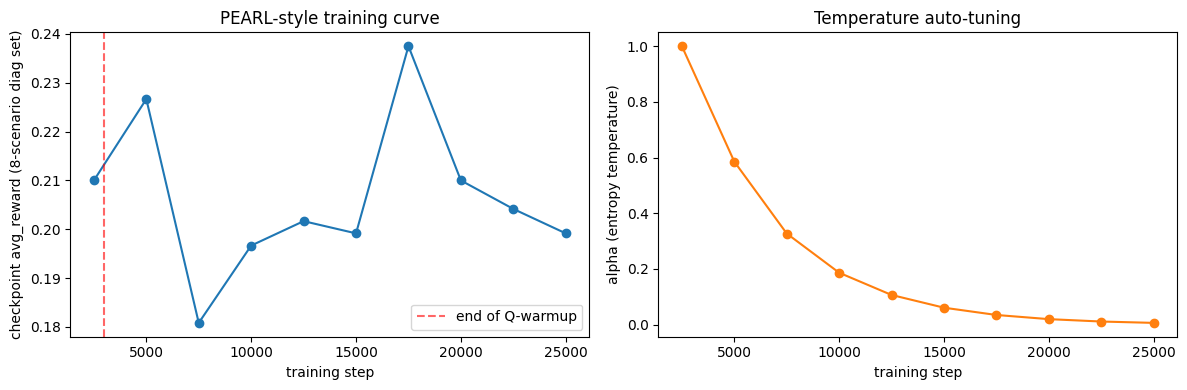

In [5]:

DIAG_SCENARIOS = make_scenarios(8, base_seed=555_000)

pearl_scheduler, pearl_eval_log = train_pearl(total_steps=25000, eval_every_steps=2500, seed=RNG_SEED,
                                               eval_scenarios=DIAG_SCENARIOS)

steps, rewards, alphas = zip(*pearl_eval_log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(steps, rewards, "o-")
axes[0].axvline(3000, color="red", linestyle="--", alpha=0.6, label="end of Q-warmup")
axes[0].set_xlabel("training step"); axes[0].set_ylabel("checkpoint avg_reward (8-scenario diag set)")
axes[0].set_title("PEARL-style training curve"); axes[0].legend()
axes[1].plot(steps, alphas, "o-", color="tab:orange")
axes[1].set_xlabel("training step"); axes[1].set_ylabel("alpha (entropy temperature)")
axes[1].set_title("Temperature auto-tuning")
plt.tight_layout()
plt.show()



## 3. Held-out comparison (25 scenarios, disjoint from training)


In [6]:

schedulers = [RoundRobinScheduler(), GreedyBeliefScheduler(), pearl_scheduler]
results = pd.DataFrame([evaluate_scheduler(s, EVAL_SCENARIOS) for s in schedulers]).set_index("scheduler")
rr = results.loc["Round-robin (open loop)", "hit_rate"]
results["vs_RR"] = results["hit_rate"] / rr
results.round(4)


,hit_rate,Pd,Pfa,avg_reward,interception_ratio,avg_intercept_delay_slots,vs_RR
scheduler,,,,,,,
Round-robin (open loop),0.1131,0.5811,0.0483,0.1131,0.7353,36.0667,1.0000
Belief-index (belief + exploration bonus),0.2133,0.6221,0.0469,0.2133,0.5392,39.4727,1.8868
PEARL-style (context-conditioned residual SAC),0.1885,0.6647,0.0483,0.1885,0.3922,39.7250,1.6675


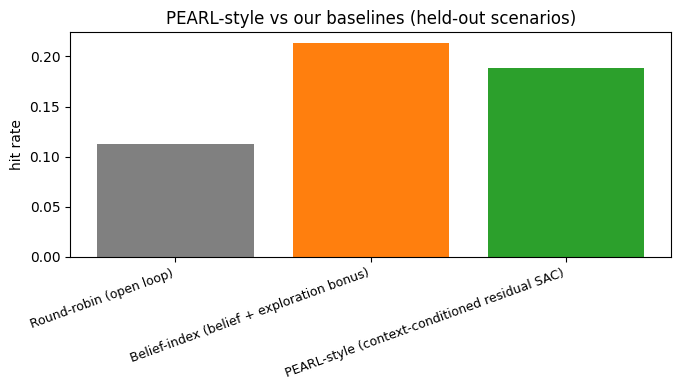

In [7]:

fig, ax = plt.subplots(figsize=(7, 4))
labels = list(results.index)
ax.bar(range(len(labels)), results["hit_rate"].values, color=["grey", "tab:orange", "tab:green"])
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("hit rate")
ax.set_title("PEARL-style vs our baselines (held-out scenarios)")
plt.tight_layout()
plt.show()


## 4. Conclusion

**Result:** the PEARL-style context-conditioned scheduler reaches **0.1885 hit rate (1.67x
round-robin)** on the held-out set -- *below* both `Belief-index` (0.2133, 1.89x) and
Notebook 2's plain `SAC-Discrete` (0.2293, 2.03x, same warm-start and stabilization, no
context). Adding context inference made things slightly worse here, not better.

**Why, given the mechanism is sound (training was stable, no collapse):** the honest
expectation set above played out. Our per-band features already encode a Bayesian belief,
staleness, empirical hit-rate, and a periodicity estimate -- a strong hand-designed summary
of *this band's* history. The context encoder's job was to additionally capture
*episode-level* structure (how many emitters, how bursty the mix) that those features don't
see directly. That's a real but narrow opportunity, and in a 12-band/150-slot episode the
context encoder has to learn something useful from a short, noisy window of recent
transitions, then have the correction head learn to exploit it correctly -- more moving
parts than plain SAC-Discrete, for a signal that's partially redundant with what belief
already captures implicitly (belief already reflects "how bursty is this band" per band,
just not "how bursty is this whole scenario").

**This is a legitimate, useful negative result, not a failed implementation:** PEARL's
20-100x sample-efficiency claim is specifically about meta-training efficiency relative to
*on-policy* meta-RL baselines on continuous-control tasks with no informative raw state --
it is not a general claim that context inference improves any RL task it's bolted onto. Here,
where the base features are already informative and the "task" (emitter scenario) is
implicitly identifiable from a handful of belief updates, the extra machinery adds training
noise without adding new information. **The practical takeaway for this project: prefer
Notebook 2's plain residual SAC-Discrete over the PEARL-style variant** -- it's simpler,
trains to a better number, and the context encoder would likely need either a much longer
per-episode history, a richer raw observation (e.g. actual PDW streams rather than
pre-aggregated belief features), or more training budget to pay for its own complexity.
